## Risk-Based A* (Flood-Aware Pathfinding)

Risk-Based A* is an informed search algorithm that improves standard A* by adding flood/risk cost awareness.

This algorithm prefers safer paths with lower water risk, even if they are slightly longer.

In this Flood Evacuation & Rescue System, Risk-Based A* is used to find a safe path from the rescue team to the victim or shelter while avoiding flooded/high-risk areas.

### Key Components of Risk-Based A*:
1. **State Representation**: Each state represents a cell in the grid, defined by its coordinates (row, column).
2. **Cost Function**: The cost function combines the actual path cost (g(n)) with a heuristic estimate (h(n)) of the remaining distance to the goal, and a risk cost (r(n)) based on flood levels:
   - f(n) = g(n) + h(n) + r(n)
   - g(n): Actual cost from start to current node.
   - h(n): Heuristic estimate (e.g., Manhattan distance) from current node to goal.
   - r(n): Risk cost based on flood levels at the current node.
3. **Priority Queue**: A priority queue is used to explore nodes based on their f(n) values, ensuring that the algorithm prioritizes safer paths.

### Implementation Steps:
1. **Define the Grid and Costs**: Create a grid representation of the environment, including flood levels and risk costs for each cell.
2. **Initialize the Search**: Start from the rescue team's location and initialize the open set (priority queue) and closed set (visited nodes).
3. **Search Loop**: While the open set is not empty:
   - Pop the node with the lowest f(n) value.
   - If it is the goal (victim or shelter), reconstruct the path and return it.
   - Otherwise, generate its neighbors and calculate their f(n) values.
   - Add valid neighbors to the open set if they haven't been visited or if a cheaper path is found.
4. **Handle No Path Found**: If the open set is exhausted without reaching the goal, return an indication that no path exists.

### **Complete Rescue Operation using (Risk-Based A*)**

In this simulation, Risk-Based A* is used in two phases:

Find safest path from Rescue Team → Victim
Find safest path from Victim → Shelter

Both paths are combined to form a complete rescue operation with minimum risk exposure.

Rescue Flow:

    Rescue Team → Victim → Shelter (Risk-Optimized Path)

In [1]:
import sys
import os
import heapq
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from Environment.grid import *


VICTIM:
[(1, 1), (4, 2), (2, 9), (6, 2)]

SHELTER:
(18, 18)

FLOOD ORIGINS:
[(9, 9), (9, 10), (10, 9), (10, 10), (11, 9), (11, 10), (12, 9), (12, 10), (15, 8), (15, 9), (16, 8), (16, 9), (17, 8), (17, 9)]

NEIGHBORS OF VICTIM:
(1, 1): [(0, 1), (2, 1), (1, 0), (1, 2)]
(4, 2): [(3, 2), (5, 2), (4, 1), (4, 3)]
(2, 9): [(1, 9), (3, 9), (2, 8), (2, 10)]
(6, 2): [(5, 2), (7, 2), (6, 1), (6, 3)]

CELL INFO (9,9):
{'type': 2, 'water_level': 1.0, 'passable': False}

MOVEMENT COST OF (8,8):
6.0

IS (3,3) PASSABLE?
False


In [2]:
# =====================================================
# RISK-BASED A* SEARCH ALGORITHM (SINGLE GOAL)
# =====================================================

def risk_astar(start, goal):

    open_set = []
    heapq.heappush(open_set, (0, start))

    g_score = {start: 0}
    parent = {start: None}

    visited = set()

    while open_set:

        current_f, current = heapq.heappop(open_set)

        if current == goal:

            path = []
            node = current

            while node is not None:
                path.append(node)
                node = parent[node]

            path.reverse()

            return path

        if current in visited:
            continue

        visited.add(current)

        for neighbor in get_neighbors(current):

            move_cost = get_risk_cost(neighbor[0], neighbor[1])

            tentative_g = g_score[current] + move_cost

            if neighbor not in g_score or tentative_g < g_score[neighbor]:

                g_score[neighbor] = tentative_g
                f_score = tentative_g + heuristic(neighbor, goal)

                parent[neighbor] = current

                heapq.heappush(open_set, (f_score, neighbor))

    return None

In [3]:
# =====================================================
# RISK-BASED A* SEARCH ALGORITHM (MULTI GOAL)
# =====================================================

def risk_astar_multi_goal(start, goals):

    goal_set = set(goals)

    open_set = []
    heapq.heappush(open_set, (0, start))

    g_score = {start: 0}
    parent = {start: None}

    visited = set()

    while open_set:

        current_f, current = heapq.heappop(open_set)

        if current in goal_set:

            path = []
            node = current

            while node is not None:
                path.append(node)
                node = parent[node]

            path.reverse()

            return path, current

        if current in visited:
            continue

        visited.add(current)

        for neighbor in get_neighbors(current):

            move_cost = get_risk_cost(neighbor[0], neighbor[1])

            tentative_g = g_score[current] + move_cost

            if neighbor not in g_score or tentative_g < g_score[neighbor]:

                g_score[neighbor] = tentative_g
                f_score = tentative_g + heuristic_multi(neighbor, goals)

                parent[neighbor] = current

                heapq.heappush(open_set, (f_score, neighbor))

    return None, None

In [4]:
# =====================================================
# TEST RISK-BASED A*
# =====================================================

start = (0, 0)

path_to_victim_risk, found_victim_risk = risk_astar_multi_goal(start, victims)
path_to_shelter_risk = risk_astar(found_victim_risk, shelter)

if path_to_victim_risk and path_to_shelter_risk:

    full_path_risk = path_to_victim_risk + path_to_shelter_risk[1:]

    print("Nearest Victim (Risk-A*):", found_victim_risk)
    print("Risk-A* Path to Victim:", len(path_to_victim_risk)-1, "steps")
    print("Risk-A* Path to Shelter:", len(path_to_shelter_risk)-1, "steps")
    print("Risk-A* Total Rescue Path:", len(full_path_risk)-1, "steps")

else:

    print("No valid rescue path found.")

Nearest Victim (Risk-A*): (1, 1)
Risk-A* Path to Victim: 2 steps
Risk-A* Path to Shelter: 34 steps
Risk-A* Total Rescue Path: 36 steps


In [17]:
path_to_victim, found_victim = risk_astar_multi_goal(start, victims)
path_to_shelter = risk_astar(found_victim, shelter)

if path_to_victim:
    print("Path Found!")
    print()
    for p in path_to_victim:
        print(p)
    print()
    print("Total Steps:", len(path_to_victim)-1)
else:
    print("No Path Found!")

if path_to_shelter:
    print("Path Found!")
    print()
    for p in path_to_shelter:
        print(p)
    print()
    print("Total Steps:", np.sum([len(path_to_shelter)-1, len(path_to_victim)-1]))

Path Found!

(0, 0)
(0, 1)
(1, 1)

Total Steps: 2
Path Found!

(1, 1)
(1, 2)
(1, 3)
(1, 4)
(1, 5)
(1, 6)
(1, 7)
(1, 8)
(1, 9)
(1, 10)
(1, 11)
(1, 12)
(1, 13)
(1, 14)
(1, 15)
(1, 16)
(1, 17)
(1, 18)
(2, 18)
(3, 18)
(4, 18)
(5, 18)
(6, 18)
(7, 18)
(8, 18)
(9, 18)
(10, 18)
(11, 18)
(12, 18)
(13, 18)
(14, 18)
(15, 18)
(16, 18)
(17, 18)
(18, 18)

Total Steps: 36


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from Environment.grid import *

def show_snapshot(title):

    # reuse SAME function style (no recoloring)
    display_grid(save_image=False)

    plt.title(title)
    plt.show()

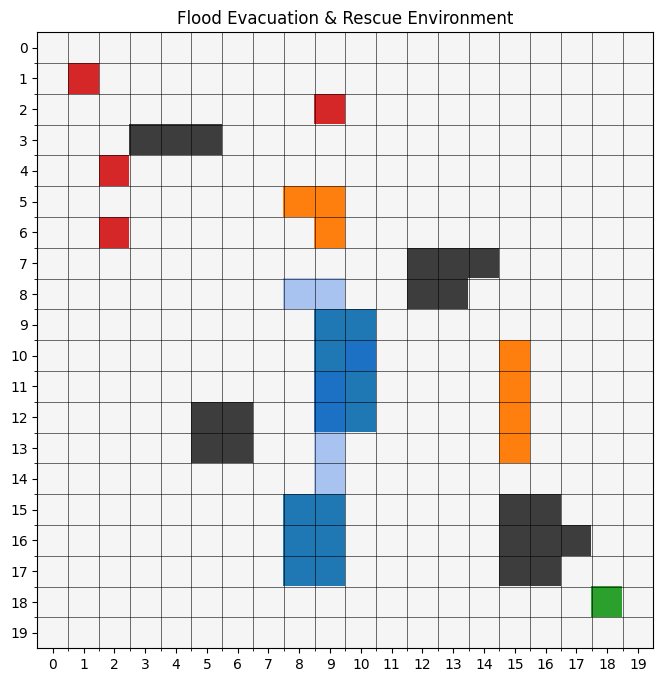

In [27]:
display_grid(save_image=False)


PATH TO VICTIM:
[(0, 0), (0, 1), (1, 1)]

Image Saved: stage2_victim_found(Risk A star).png


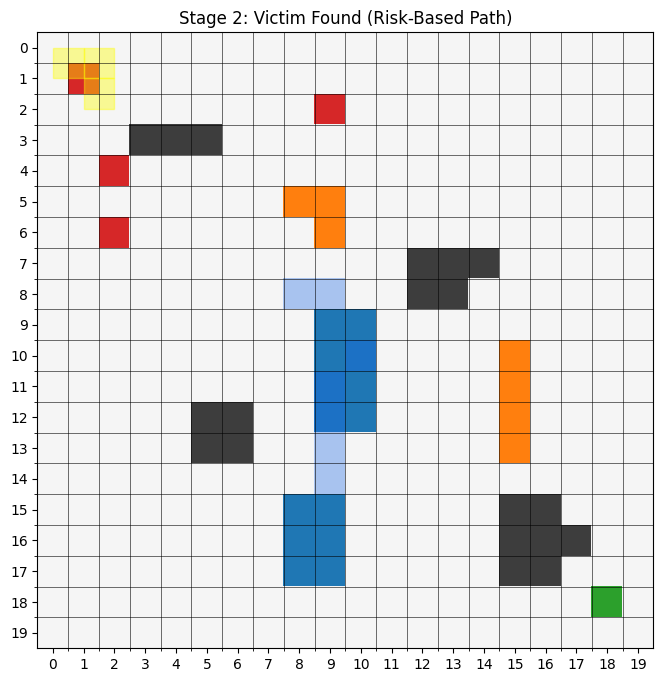

In [24]:
# =====================================================
# STAGE 2: RISK-BASED PATH TO VICTIM
# =====================================================

def display_path_to_victim(path_to_victim, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    # ==========================================
    # RISKY CELL OVERLAY
    # ==========================================

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    # ==========================================
    # HIGHLIGHT BFS PATH
    # ==========================================

    for r, c in path_to_victim:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="yellow",
                alpha=0.4
            )
        )

    # ==========================================
    # GRID LINES
    # ==========================================

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 2: Victim Found (Risk-Based Path)"
    )

    # ==========================================
    # SAVE IMAGE FOR GITHUB
    # ==========================================

    if save_image:

        plt.savefig(
            "../images/stage2_victim_found(Risk A star).png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: stage2_victim_found(Risk A star).png"
        )

    plt.show()
path_to_victim, found_victim = risk_astar_multi_goal(start, victims)
print("\nPATH TO VICTIM:")
print(path_to_victim)

display_path_to_victim(path_to_victim)


FULL RESCUE PATH:
[(0, 0), (0, 1), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (2, 18), (3, 18), (4, 18), (5, 18), (6, 18), (7, 18), (8, 18), (9, 18), (10, 18), (11, 18), (12, 18), (13, 18), (14, 18), (15, 18), (16, 18), (17, 18), (18, 18)]

Image Saved: stage3_full_rescue_Risk_AStar.png


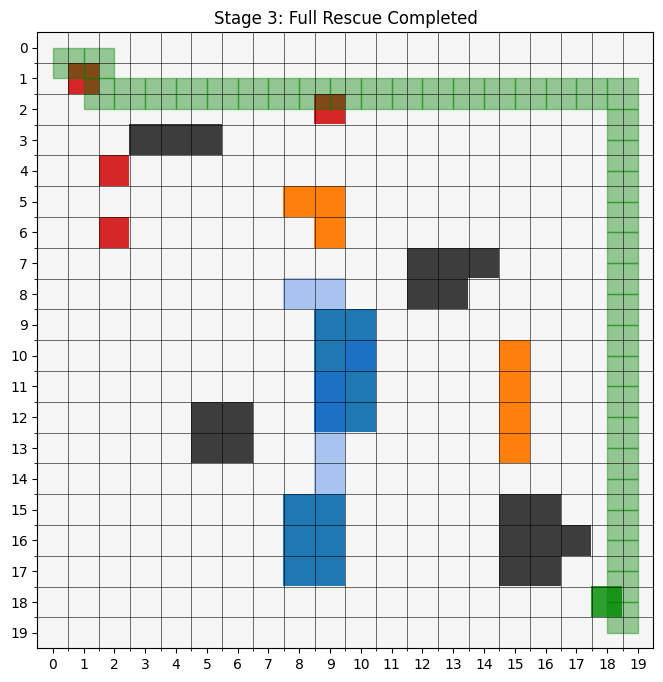

In [25]:
# =====================================================
# STAGE 3: FULL RESCUE PATH (VICTIM TO SHELTER)
# =====================================================

def display_full_rescue_path(full_path, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    # ==========================================
    # RISKY CELL OVERLAY
    # ==========================================

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD
            ):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    # ==========================================
    # HIGHLIGHT FULL PATH
    # ==========================================

    for r, c in full_path:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="green",
                alpha=0.4
            )
        )

    # ==========================================
    # GRID LINES
    # ==========================================

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 3: Full Rescue Completed"
    )

    # ==========================================
    # SAVE IMAGE FOR GITHUB
    # ==========================================

    if save_image:

        plt.savefig(
            "../images/stage3_full_rescue_Risk_AStar.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: stage3_full_rescue_Risk_AStar.png"
        )

    plt.show()
path_to_shelter = risk_astar(found_victim, shelter)
full_path = path_to_victim + path_to_shelter[1:]

print("\nFULL RESCUE PATH:")
print(full_path)

display_full_rescue_path(full_path)